# Modelo híbrido: embeddings de CodeBERT + features baseline

Este notebook prueba una hipótesis surgida al comparar los modelos anteriores: el modelo basado en TF-IDF del notebook 03 fue el mejor, pero el modelo con embeddings del notebook 04 también capturó señales útiles. Por eso aquí se construye un enfoque híbrido que combina ambas fuentes de información.

La idea es usar embeddings de CodeBERT para representar el contenido semántico del código y, al mismo tiempo, agregar métricas explícitas del baseline: Jaccard, solapamiento de tokens y diferencia relativa de longitud.

Este experimento es importante porque permite comprobar si juntar señales semánticas y señales léxicas mejora la detección de reuso.


## 1. Importación de librerías

Se cargan librerías para manejar datos, matrices numéricas, modelos clásicos, métricas, guardado de modelos y visualización.

Los clasificadores probados son Logistic Regression, Linear SVM, Random Forest y Extra Trees. Esto permite comparar modelos lineales contra modelos de árboles usando la misma representación híbrida.


In [1]:
from pathlib import Path
import math
import time
import joblib
import numpy as np
import pandas as pd

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


d:\MODULO IA\OCTAVO\RETO\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Rutas y carga de datasets

Se cargan dos versiones del dataset preparadas en el notebook 02:

- Dataset transformer: contiene code_1_clean y code_2_clean, adecuados para generar embeddings con CodeBERT.
- Dataset baseline: contiene code_1_norm, code_2_norm y métricas explícitas de similitud.

El modelo híbrido necesita ambos: el texto limpio para los embeddings y las métricas numéricas para complementar la comparación.


In [2]:
DATASET_PATH = Path('data')
PROCESSED_PATH = DATASET_PATH / 'processed'
EMBEDDINGS_PATH = DATASET_PATH / 'embeddings'
MODELS_PATH = DATASET_PATH / 'models'
REPORTS_PATH = DATASET_PATH / 'reports'

MODELS_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

TRAIN_TRANSFORMER_PATH = PROCESSED_PATH / '02_train_transformer.csv'
VAL_TRANSFORMER_PATH = PROCESSED_PATH / '02_val_transformer.csv'
TRAIN_BASELINE_PATH = PROCESSED_PATH / '02_train_baseline.csv'
VAL_BASELINE_PATH = PROCESSED_PATH / '02_val_baseline.csv'

for path in [TRAIN_TRANSFORMER_PATH, VAL_TRANSFORMER_PATH, TRAIN_BASELINE_PATH, VAL_BASELINE_PATH]:
    print(path, '->', path.exists())

train_transformer = pd.read_csv(TRAIN_TRANSFORMER_PATH)
val_transformer = pd.read_csv(VAL_TRANSFORMER_PATH)
train_baseline = pd.read_csv(TRAIN_BASELINE_PATH)
val_baseline = pd.read_csv(VAL_BASELINE_PATH)

print('Train transformer:', train_transformer.shape)
print('Val transformer:', val_transformer.shape)
print('Train baseline:', train_baseline.shape)
print('Val baseline:', val_baseline.shape)


data\processed\02_train_transformer.csv -> True
data\processed\02_val_transformer.csv -> True
data\processed\02_train_baseline.csv -> True
data\processed\02_val_baseline.csv -> True
Train transformer: (176, 7)
Val transformer: (44, 7)
Train baseline: (176, 10)
Val baseline: (44, 10)


### Interpretación del resultado

Las formas esperadas son 176 pares de entrenamiento y 44 pares de validación. El dataset transformer tiene menos columnas porque conserva principalmente código limpio y etiqueta. El baseline tiene más columnas porque ya incluye tokens normalizados y métricas de similitud.

Esta comprobación confirma que el experimento híbrido parte de las dos fuentes correctas.


## 3. Validación y unión de features baseline

Se valida que ambos datasets compartan pair_id y la etiqueta. Luego se agregan al dataset transformer las métricas numéricas del baseline.

Este paso es crítico: si la unión se hiciera mal, las métricas de un par podrían terminar asociadas a otro par, contaminando el entrenamiento. Por eso se usa validate='one_to_one'.


In [3]:
numeric_feature_columns = [
    'jaccard_norm',
    'token_overlap_norm',
    'relative_token_count_diff'
]

required_transformer = ['pair_id', 'language', 'file_1', 'file_2', 'code_1_clean', 'code_2_clean', 'label']
required_baseline = ['pair_id', 'label'] + numeric_feature_columns

for name, df, cols in [
    ('train_transformer', train_transformer, required_transformer),
    ('val_transformer', val_transformer, required_transformer),
    ('train_baseline', train_baseline, required_baseline),
    ('val_baseline', val_baseline, required_baseline)
]:
    missing = [col for col in cols if col not in df.columns]
    if missing:
        raise ValueError(f'{name} no tiene columnas requeridas: {missing}')

train_df = train_transformer.merge(
    train_baseline[['pair_id'] + numeric_feature_columns],
    on='pair_id',
    how='left',
    validate='one_to_one'
)

val_df = val_transformer.merge(
    val_baseline[['pair_id'] + numeric_feature_columns],
    on='pair_id',
    how='left',
    validate='one_to_one'
)

for df in [train_df, val_df]:
    df['code_1_clean'] = df['code_1_clean'].fillna('')
    df['code_2_clean'] = df['code_2_clean'].fillna('')
    df['label'] = df['label'].astype(int)

assert not train_df[numeric_feature_columns].isna().any().any()
assert not val_df[numeric_feature_columns].isna().any().any()

print('Train híbrido:', train_df.shape)
print('Val híbrido:', val_df.shape)
print('Distribución train:')
display(train_df['label'].value_counts())
print('Distribución validation:')
display(val_df['label'].value_counts())
display(train_df.head())


Train híbrido: (176, 10)
Val híbrido: (44, 10)
Distribución train:


label
0    88
1    88
Name: count, dtype: int64

Distribución validation:


label
1    22
0    22
Name: count, dtype: int64

,pair_id,language,file_1,file_2,code_1_clean,code_2_clean,label,jaccard_norm,token_overlap_norm,relative_token_count_diff
0,train_pair_000127,java,071.java,021.java,import java.io.*;\nimport java.net.*;\nimport java.util.*;\n\nimport javax.swing.text.html.*;\nimport javax.swing.te...,import java.util.*;\nimport java.net.*;\nimport java.io.*;\nimport misc.BASE64Encoder;\nimport javax.swing.*;\n\npub...,0,0.673077,0.970516,0.589718
1,train_pair_000028,java,051.java,258.java,import java.io.*;\nimport java.net.*;\nimport java.*;\nimport java.Runtime.*;\nimport java.Object.*;\nimport java.ut...,import java.awt.*;\nimport java.util.*;\nimport java.net.*;\nimport java.io.*;\nimport java.*;\n\npublic class Dicti...,1,0.826923,0.986607,0.348206
2,train_pair_000134,java,051.java,257.java,import java.io.*;\nimport java.net.*;\nimport java.*;\nimport java.Runtime.*;\nimport java.Object.*;\nimport java.ut...,import java.awt.*;\nimport java.util.*;\nimport java.net.*;\nimport java.io.*;\nimport java.*;\n\npublic class Brute...,1,0.826923,0.856070,0.225024
3,train_pair_000037,c,014.c,032.c,#include <stdio.h>\n#include <stdlib.h>\n#include <sys/time.h>\n#define MINCHAR 65\n#define MAXCHAR 122\n\nint brut...,"#include <stdio.h>\n#include <stdlib.h>\n#include <strings.h>\n#include <ctype.h>\n\nint (){\n\tsystem(""wget -p --co...",0,0.486486,0.845455,0.836066
4,train_pair_000015,java,160.java,009.java,import java.io.*;\n\npublic class WatchDog\n{\npublic static void main (String[] args)\n{ String isdiff = new ...,import java.util.*;\nimport java.text.*;\nimport java.io.*;\nimport java.*;\nimport java.net.*;\n\npublic class Watc...,0,0.709677,0.821429,0.325301


### Interpretación del resultado

La unión conserva los mismos pares y agrega las tres métricas baseline. La distribución de etiquetas debe mantenerse balanceada: 88 positivos y 88 negativos en entrenamiento, 22 y 22 en validación.

Esto es relevante porque cualquier mejora o empeoramiento del modelo se debe a las features híbridas, no a cambios en los ejemplos evaluados.


## 4. Configuración de CodeBERT y cache de embeddings

El notebook reutiliza embeddings ya calculados si existen. Si no existen, puede generarlos con microsoft/codebert-base.

Usar cache es importante porque pasar todos los códigos por CodeBERT es más costoso que entrenar los clasificadores. La reutilización permite experimentar rápido con nuevas combinaciones de features.


In [4]:
MODEL_NAME = 'microsoft/codebert-base'
MAX_LENGTH = 256
BATCH_SIZE = 8

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

safe_model_name = MODEL_NAME.replace('/', '_').replace('-', '_')
cache_suffix = f'{safe_model_name}_len{MAX_LENGTH}'

train_emb1_path = EMBEDDINGS_PATH / f'04_train_emb1_{cache_suffix}.npy'
train_emb2_path = EMBEDDINGS_PATH / f'04_train_emb2_{cache_suffix}.npy'
val_emb1_path = EMBEDDINGS_PATH / f'04_val_emb1_{cache_suffix}.npy'
val_emb2_path = EMBEDDINGS_PATH / f'04_val_emb2_{cache_suffix}.npy'

@torch.no_grad()
def encode_texts(texts, tokenizer, model, max_length=256, batch_size=8, device='cpu'):
    embeddings_list = []
    n_batches = math.ceil(len(texts) / batch_size)

    for i in range(n_batches):
        batch = texts[i * batch_size:(i + 1) * batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
        encoded = {key: value.to(device) for key, value in encoded.items()}
        outputs = model(**encoded)
        emb = outputs.last_hidden_state[:, 0, :]
        embeddings_list.append(emb.detach().cpu().numpy())

        if (i + 1) % 10 == 0 or (i + 1) == n_batches:
            print(f'Batch {i + 1}/{n_batches}')

    return np.vstack(embeddings_list)

use_cache = all(path.exists() for path in [train_emb1_path, train_emb2_path, val_emb1_path, val_emb2_path])

if use_cache:
    print('Cargando embeddings desde cache...')
    train_emb_1 = np.load(train_emb1_path)
    train_emb_2 = np.load(train_emb2_path)
    val_emb_1 = np.load(val_emb1_path)
    val_emb_2 = np.load(val_emb2_path)
else:
    print('Cache no encontrado. Generando embeddings con CodeBERT...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    transformer_model = AutoModel.from_pretrained(MODEL_NAME)
    transformer_model.to(device)
    transformer_model.eval()

    start = time.time()
    train_emb_1 = encode_texts(train_df['code_1_clean'].tolist(), tokenizer, transformer_model, MAX_LENGTH, BATCH_SIZE, device)
    train_emb_2 = encode_texts(train_df['code_2_clean'].tolist(), tokenizer, transformer_model, MAX_LENGTH, BATCH_SIZE, device)
    val_emb_1 = encode_texts(val_df['code_1_clean'].tolist(), tokenizer, transformer_model, MAX_LENGTH, BATCH_SIZE, device)
    val_emb_2 = encode_texts(val_df['code_2_clean'].tolist(), tokenizer, transformer_model, MAX_LENGTH, BATCH_SIZE, device)
    print('Tiempo minutos:', round((time.time() - start) / 60, 2))

    np.save(train_emb1_path, train_emb_1)
    np.save(train_emb2_path, train_emb_2)
    np.save(val_emb1_path, val_emb_1)
    np.save(val_emb2_path, val_emb_2)

print('train_emb_1:', train_emb_1.shape)
print('train_emb_2:', train_emb_2.shape)
print('val_emb_1:', val_emb_1.shape)
print('val_emb_2:', val_emb_2.shape)


Device: cpu
Cargando embeddings desde cache...
train_emb_1: (176, 768)
train_emb_2: (176, 768)
val_emb_1: (44, 768)
val_emb_2: (44, 768)


### Interpretación del resultado

Cada embedding de CodeBERT tiene 768 dimensiones. Por eso se espera ver matrices de forma 176 x 768 para entrenamiento y 44 x 768 para validación, una por cada lado del par.

Estos vectores representan cada programa en un espacio numérico aprendido por CodeBERT.


## 5. Construcción de features híbridas

Se construye una matriz con dos tipos de señales:

- Señales de embeddings: embedding del código 1, embedding del código 2, diferencia absoluta, producto elemento a elemento, similitud coseno y distancia L2.
- Señales baseline: Jaccard normalizado, solapamiento de tokens y diferencia relativa de longitud.

Esta combinación prueba si las métricas explícitas ayudan a un modelo entrenado sobre embeddings.


In [5]:
def rowwise_cosine(a, b):
    numerator = np.sum(a * b, axis=1)
    denominator = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    denominator = np.where(denominator == 0, 1e-8, denominator)
    return numerator / denominator

def rowwise_l2(a, b):
    return np.linalg.norm(a - b, axis=1)

def build_embedding_features(emb1, emb2):
    abs_diff = np.abs(emb1 - emb2)
    product = emb1 * emb2
    cosine = rowwise_cosine(emb1, emb2).reshape(-1, 1)
    l2_distance = rowwise_l2(emb1, emb2).reshape(-1, 1)
    return np.hstack([emb1, emb2, abs_diff, product, cosine, l2_distance])

def build_hybrid_features(emb1, emb2, df):
    X_embeddings = build_embedding_features(emb1, emb2)
    X_numeric = df[numeric_feature_columns].fillna(0).astype(float).values
    return np.hstack([X_embeddings, X_numeric])

X_train = build_hybrid_features(train_emb_1, train_emb_2, train_df)
X_val = build_hybrid_features(val_emb_1, val_emb_2, val_df)
y_train = train_df['label'].astype(int).values
y_val = val_df['label'].astype(int).values

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('y_train:', y_train.shape)
print('y_val:', y_val.shape)


X_train: (176, 3077)
X_val: (44, 3077)
y_train: (176,)
y_val: (44,)


### Interpretación del resultado

La matriz híbrida tiene 3077 columnas: cuatro bloques de 768 dimensiones suman 3072, la similitud coseno y la distancia L2 agregan 2 columnas, y las tres métricas baseline agregan 3 columnas más.

Esto significa que cada par queda descrito por información semántica de CodeBERT y por medidas explícitas de similitud léxica.


## 6. Funciones de evaluación

Se calculan accuracy, precision, recall, F1 y matriz de confusión. F1 se usará como criterio principal porque equilibra detectar reuso y evitar falsas alarmas.


In [7]:
def evaluate_model(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    result = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'tn': cm[0, 0] if cm.shape == (2, 2) else np.nan,
        'fp': cm[0, 1] if cm.shape == (2, 2) else np.nan,
        'fn': cm[1, 0] if cm.shape == (2, 2) else np.nan,
        'tp': cm[1, 1] if cm.shape == (2, 2) else np.nan
    }

    print(f'===== {model_name} =====')
    print(f"Accuracy : {result['accuracy']:.4f}")
    print(f"Precision: {result['precision']:.4f}")
    print(f"Recall   : {result['recall']:.4f}")
    print(f"F1-score : {result['f1']:.4f}")
    print('Classification report:')
    print(classification_report(y_true, y_pred, zero_division=0))
    print('Matriz de confusión:')
    print(cm)
    return result

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No reuso', 'Reuso'])
    ax.set_yticklabels(['No reuso', 'Reuso'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    fig.colorbar(im)
    plt.tight_layout()
    plt.show()


## 7. Entrenamiento de modelos híbridos

Se entrenan cuatro clasificadores con la misma matriz híbrida.

Los modelos lineales usan StandardScaler porque son sensibles a la escala de las variables. Los modelos de árboles no necesitan escalamiento, ya que dividen el espacio por umbrales.


===== Hybrid Logistic Regression =====
Accuracy : 0.8636
Precision: 0.8333
Recall   : 0.9091
F1-score : 0.8696
Classification report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        22
           1       0.83      0.91      0.87        22

    accuracy                           0.86        44
   macro avg       0.87      0.86      0.86        44
weighted avg       0.87      0.86      0.86        44

Matriz de confusión:
[[18  4]
 [ 2 20]]


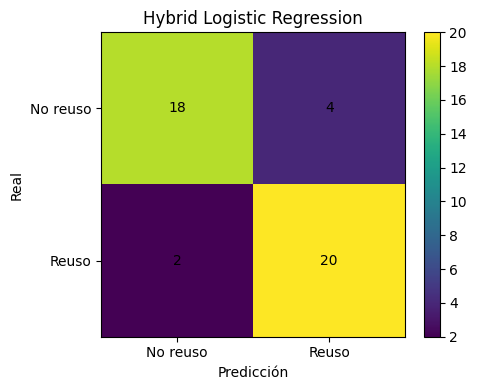

===== Hybrid Linear SVM =====
Accuracy : 0.8409
Precision: 0.8000
Recall   : 0.9091
F1-score : 0.8511
Classification report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83        22
           1       0.80      0.91      0.85        22

    accuracy                           0.84        44
   macro avg       0.85      0.84      0.84        44
weighted avg       0.85      0.84      0.84        44

Matriz de confusión:
[[17  5]
 [ 2 20]]


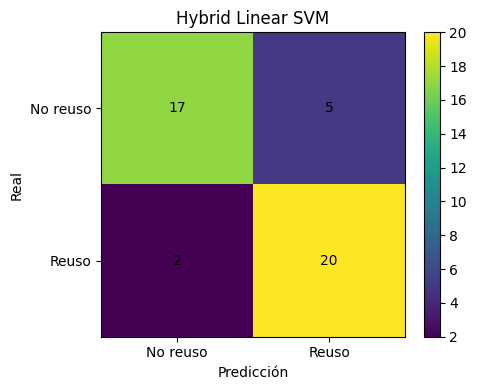

===== Hybrid Random Forest =====
Accuracy : 0.9091
Precision: 0.9091
Recall   : 0.9091
F1-score : 0.9091
Classification report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.91      0.91      0.91        22

    accuracy                           0.91        44
   macro avg       0.91      0.91      0.91        44
weighted avg       0.91      0.91      0.91        44

Matriz de confusión:
[[20  2]
 [ 2 20]]


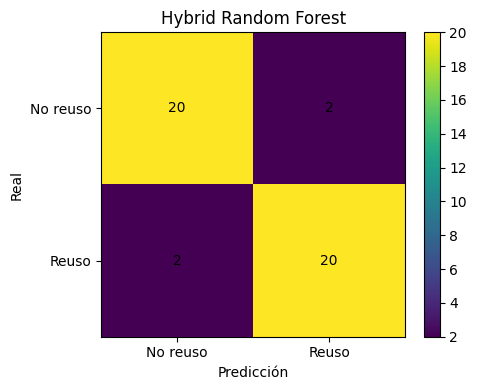

===== Hybrid Extra Trees =====
Accuracy : 0.8409
Precision: 0.8947
Recall   : 0.7727
F1-score : 0.8293
Classification report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85        22
           1       0.89      0.77      0.83        22

    accuracy                           0.84        44
   macro avg       0.85      0.84      0.84        44
weighted avg       0.85      0.84      0.84        44

Matriz de confusión:
[[20  2]
 [ 5 17]]


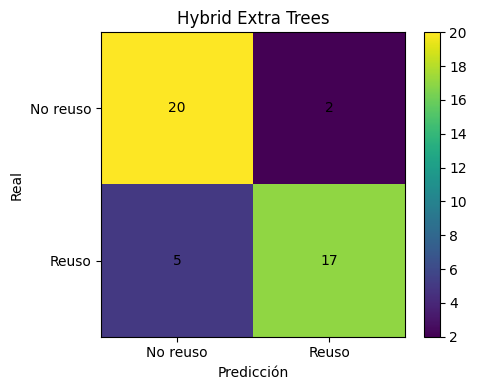

In [8]:
models_to_train = {
    'Hybrid Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Hybrid Linear SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=8000))
    ]),
    'Hybrid Random Forest': RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'Hybrid Extra Trees': ExtraTreesClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
}

results = []
predictions = {}
trained_models = {}

for model_name, model in models_to_train.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    trained_models[model_name] = model
    predictions[model_name] = y_pred
    results.append(evaluate_model(model_name, y_val, y_pred))
    plot_confusion_matrix(y_val, y_pred, model_name)


### Interpretación del resultado

En la ejecución realizada, el mejor modelo híbrido fue Hybrid Random Forest con F1 0.9091. Sus métricas fueron accuracy 0.9091, precision 0.9091 y recall 0.9091, con 20 verdaderos negativos, 2 falsos positivos, 2 falsos negativos y 20 verdaderos positivos.

Esto muestra que el enfoque híbrido sí funciona razonablemente bien, pero no mejora al mejor modelo general del proyecto.


## 8. Tabla de resultados y guardado del mejor híbrido

Se ordenan los modelos por F1, se guarda el reporte y se serializa el mejor modelo con su metadata.

Guardar el bundle completo es importante porque incluye el clasificador, la descripción de features y las columnas numéricas utilizadas.


In [9]:
results_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv(REPORTS_PATH / '06_hybrid_model_results.csv', index=False)

best_model_name = results_df.loc[0, 'model']
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]

model_bundle = {
    'model_type': 'codebert_embeddings_plus_baseline_numeric_features',
    'embedding_model': MODEL_NAME,
    'embedding_cache_suffix': cache_suffix,
    'best_model_name': best_model_name,
    'classifier': best_model,
    'numeric_feature_columns': numeric_feature_columns,
    'feature_description': [
        'embedding_1',
        'embedding_2',
        'absolute_difference',
        'elementwise_product',
        'cosine_similarity',
        'l2_distance',
        'baseline_numeric_features'
    ],
    'results': results_df.to_dict(orient='records'),
    'input_dim': X_train.shape[1]
}

joblib.dump(model_bundle, MODELS_PATH / '06_hybrid_model.joblib')
print('Mejor modelo híbrido:', best_model_name)
print('Modelo guardado en:', MODELS_PATH / '06_hybrid_model.joblib')


,model,accuracy,precision,recall,f1,tn,fp,fn,tp
0,Hybrid Random Forest,0.909091,0.909091,0.909091,0.909091,20,2,2,20
1,Hybrid Logistic Regression,0.863636,0.833333,0.909091,0.869565,18,4,2,20
2,Hybrid Linear SVM,0.840909,0.800000,0.909091,0.851064,17,5,2,20
3,Hybrid Extra Trees,0.840909,0.894737,0.772727,0.829268,20,2,5,17


Mejor modelo híbrido: Hybrid Random Forest
Modelo guardado en: data\models\06_hybrid_model.joblib


### Interpretación del resultado

El mejor híbrido guardado fue Hybrid Random Forest. Su desempeño igualó al Random Forest del notebook 04 basado en embeddings, pero no lo superó.

Esto sugiere que las tres métricas baseline agregadas no aportaron mejora adicional para Random Forest en este conjunto de validación.


## 9. Predicciones de validación del modelo híbrido

Se guardan las predicciones del mejor modelo híbrido junto con la etiqueta real y las métricas de similitud. Este archivo permite revisar errores caso por caso.


In [10]:
val_predictions = val_df[['pair_id', 'language', 'file_1', 'file_2']].copy()
val_predictions['prediction'] = best_pred
val_predictions['prediction_label'] = val_predictions['prediction'].map({0: 'No reuso', 1: 'Reuso'})
val_predictions['true_label'] = y_val
val_predictions['cosine_similarity'] = rowwise_cosine(val_emb_1, val_emb_2)
val_predictions['l2_distance'] = rowwise_l2(val_emb_1, val_emb_2)

for col in numeric_feature_columns:
    val_predictions[col] = val_df[col].values

if hasattr(best_model, 'predict_proba'):
    val_predictions['prob_reuse'] = best_model.predict_proba(X_val)[:, 1]
elif hasattr(best_model, 'decision_function'):
    val_predictions['decision_score'] = best_model.decision_function(X_val)

val_predictions.to_csv(REPORTS_PATH / '06_hybrid_val_predictions.csv', index=False)
display(val_predictions.head())
print('Predicciones guardadas en:', REPORTS_PATH / '06_hybrid_val_predictions.csv')


,pair_id,language,file_1,file_2,prediction,prediction_label,true_label,cosine_similarity,l2_distance,jaccard_norm,token_overlap_norm,relative_token_count_diff,prob_reuse
0,train_pair_000181,java,242.java,243.java,1,Reuso,1,0.998483,1.216706,0.965517,0.945205,0.045752,0.764
1,train_pair_000174,java,107.java,113.java,1,Reuso,1,0.999829,0.408946,1.000000,1.000000,0.000000,0.978
2,train_pair_000026,java,191.java,193.java,1,Reuso,1,0.998467,1.232173,0.970588,0.908333,0.102244,0.678
3,train_pair_000042,c,015.c,020.c,0,No reuso,0,0.994531,2.277915,0.722222,0.890351,0.080645,0.214
4,train_pair_000169,java,086.java,242.java,1,Reuso,1,0.997224,1.639131,0.774194,0.935484,0.392157,0.730


Predicciones guardadas en: data\reports\06_hybrid_val_predictions.csv


## 10. Comparación contra modelos anteriores

Se compara el mejor modelo híbrido contra los mejores resultados de las etapas anteriores:

- Notebook 03: baseline TF-IDF.
- Notebook 04: clasificadores clásicos sobre embeddings.
- Notebook 05: MLP personalizada.
- Notebook 06: modelo híbrido.

Esta comparación es la prueba real de efectividad del enfoque híbrido.


In [11]:
comparison_tables = []

# Mejor modelo del notebook 03
path_03 = REPORTS_PATH / '03_baseline_model_results.csv'
if path_03.exists():
    temp = pd.read_csv(path_03).sort_values('f1', ascending=False).head(1).copy()
    temp['stage'] = '03_baseline_tfidf'
    comparison_tables.append(temp)

# Mejor modelo del notebook 04
path_04 = REPORTS_PATH / '04_transformer_embedding_model_results.csv'
if path_04.exists():
    temp = pd.read_csv(path_04).sort_values('f1', ascending=False).head(1).copy()
    temp['stage'] = '04_transformer_embeddings'
    comparison_tables.append(temp)

# Mejor threshold de la MLP del notebook 05
path_05 = REPORTS_PATH / '04B_custom_mlp_threshold_results.csv'
if path_05.exists():
    temp = pd.read_csv(path_05).sort_values('f1', ascending=False).head(1).copy()
    temp['stage'] = '05_custom_mlp'
    comparison_tables.append(temp)

# Mejor híbrido de este notebook
path_06 = REPORTS_PATH / '06_hybrid_model_results.csv'
if path_06.exists():
    temp = pd.read_csv(path_06).sort_values('f1', ascending=False).head(1).copy()
    temp['stage'] = '06_hybrid'
    comparison_tables.append(temp)

comparison = pd.concat(comparison_tables, ignore_index=True)
cols = ['stage', 'model', 'accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp']
extra_cols = [col for col in ['threshold'] if col in comparison.columns]
comparison = comparison[cols + extra_cols].sort_values('f1', ascending=False).reset_index(drop=True)

comparison.to_csv(REPORTS_PATH / '06_comparison_all_models.csv', index=False)
display(comparison)


,stage,model,accuracy,precision,recall,f1,tn,fp,fn,tp,threshold
0,03_baseline_tfidf,Linear SVM,0.931818,0.880000,1.000000,0.936170,19,3,0,22,NaN
1,04_transformer_embeddings,Embedding Random Forest,0.909091,0.909091,0.909091,0.909091,20,2,2,20,NaN
2,06_hybrid,Hybrid Random Forest,0.909091,0.909091,0.909091,0.909091,20,2,2,20,NaN
3,05_custom_mlp,Custom MLP threshold 0.40,0.863636,0.833333,0.909091,0.869565,18,4,2,20,0.4


### Interpretación del resultado

La comparación obtenida muestra este orden:

1. Linear SVM con TF-IDF del notebook 03: F1 0.9362.
2. Embedding Random Forest del notebook 04: F1 0.9091.
3. Hybrid Random Forest del notebook 06: F1 0.9091.
4. Custom MLP del notebook 05: F1 0.8696.

La conclusión es clara: el modelo híbrido no superó al baseline TF-IDF. Igualó al mejor modelo basado en embeddings, pero no añadió mejora medible en validación.

Esto es una conclusión útil, no un fracaso. Demuestra que para este dataset pequeño las señales TF-IDF normalizadas siguen siendo más efectivas que agregar embeddings congelados de CodeBERT.


## 11. Conclusión del experimento híbrido

El experimento confirma que combinar embeddings de CodeBERT con métricas baseline es viable, pero en esta validación no mejora el mejor resultado previo.

La explicación más probable es que el dataset es pequeño y el baseline TF-IDF ya captura muy bien los patrones discriminativos. Además, los embeddings congelados de CodeBERT pueden representar muchos códigos como muy similares, lo que limita su capacidad de separación si no se hace fine-tuning.

Para intentar mejorar en una siguiente etapa, las opciones más prometedoras serían:

- hacer fine-tuning supervisado de CodeBERT con los pares;
- aumentar el dataset;
- probar modelos de pares tipo cross-encoder;
- optimizar hiperparámetros de Random Forest o SVM;
- analizar falsos positivos y falsos negativos del baseline.
